In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

## Task 1 — A Single Neuron in NumPy

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
w = np.random.randn(30) * 0.01
b = np.random.randn() * 0.01

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [7]:
def forward(x, w, b):
    z = np.dot(x, w) + b
    return sigmoid(z)

In [8]:
sample_X = X_test[:5]
predictions = [forward(row, w, b) for row in sample_X]

In [9]:
print("Predicted Probabilities for the first 5 test rows:")
for i, prob in enumerate(predictions):
    print(f"Row {i+1}: {prob:.4f}")

Predicted Probabilities for the first 5 test rows:
Row 1: 0.4962
Row 2: 0.5175
Row 3: 0.5071
Row 4: 0.4874
Row 5: 0.4839


This is Logistic Regression implementation as a single neuron.

## Task 2 — A Two-Layer MLP in NumPy

In [10]:
class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1):
        # He Initialization: sqrt(2 / fan_in)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2/input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2/hidden_size)
        self.b2 = np.zeros((1, output_size))

    def relu(self, z):
        return np.maximum(0, z)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        # Layer 1: Input to Hidden
        # X: (N, 30), W1: (30, 8) -> Z1: (N, 8)
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)

        # Layer 2: Hidden to Output
        # A1: (N, 8), W2: (8, 1) -> Z2: (N, 1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)

        return self.A2

In [11]:
# Initialize the network
mlp = NumpyMLP(input_size=30, hidden_size=8, output_size=1)

In [12]:
# Run forward pass on the entire test set (X_test from previous task)
predictions = mlp.forward(X_test)

print(f"Output Shape: {predictions.shape}")
print("First 5 Predictions:")
print(predictions[:5])

Output Shape: (114, 1)
First 5 Predictions:
[[0.52073256]
 [0.12562479]
 [0.54742783]
 [0.42673528]
 [0.44082567]]


The output shape is determined by the **structural design (Linear Algebra)** of our weight matrices, not the values inside them.

* **Matrix Dimensions:** Our final weight matrix $W_2$ has a shape of $(8, 1)$. When we multiply our hidden layer output $(N, 8)$ by this matrix, the math forces the result to be $(N, 1)$.
* **The Activation:** The Sigmoid function then squashes those single values into the $0–1$ range.

Even with random weights, we have built a "pipe" that only allows data to come out in the form of $N$ probabilities. Training simply adjusts the weights so those probabilities become accurate.

## Task 3 — The Same Network in PyTorch

In [13]:
class TorchMLP(nn.Module):
    def __init__(self, input_size=30, hidden_size=8, output_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out

model = TorchMLP(input_size=30, hidden_size=8, output_size=1)

In [14]:
# Manually copy weights and biases from the NumpyMLP instance (mlp)
# PyTorch stores weights as (out_features, in_features), so we transpose NumPy's (in, out)
with torch.no_grad():
    model.fc1.weight.copy_(torch.from_numpy(mlp.W1.T).float())
    model.fc1.bias.copy_(torch.from_numpy(mlp.b1.flatten()).float())

    model.fc2.weight.copy_(torch.from_numpy(mlp.W2.T).float())
    model.fc2.bias.copy_(torch.from_numpy(mlp.b2.flatten()).float())

In [15]:
# Run a forward pass on the test set
X_test_tensor = torch.from_numpy(X_test).float()
model.eval()  # Set to evaluation mode
with torch.no_grad():
    torch_output = model(X_test_tensor).numpy()

In [16]:
numpy_output = mlp.forward(X_test)
max_diff = np.max(np.abs(torch_output - numpy_output))

print(f"PyTorch Output Shape: {torch_output.shape}")
print("First 5 predictions (PyTorch):")
print(torch_output[:5].flatten())
print("\nFirst 5 predictions (NumPy):")
print(numpy_output[:5].flatten())
print(f"\nMaximum Absolute Difference: {max_diff:.10e}")

PyTorch Output Shape: (114, 1)
First 5 predictions (PyTorch):
[0.5207326  0.12562476 0.54742783 0.42673525 0.4408257 ]

First 5 predictions (NumPy):
[0.52073256 0.12562479 0.54742783 0.42673528 0.44082567]

Maximum Absolute Difference: 7.8336887810e-08


## Task 4 — Activation Function Experiment

In [17]:
class ExperimentMLP(nn.Module):
    def __init__(self, activation_fn):
        super().__init__()
        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)
        self.activation = activation_fn

        # Consistent initialization for fair comparison
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.zeros_(self.fc1.bias)

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.activation(z1)
        out = torch.sigmoid(self.fc2(a1))
        return z1, a1, out

# Define variants
activations = {
    "Sigmoid": torch.sigmoid,
    "Tanh": torch.tanh,
    "ReLU": torch.relu
}

# Data collection
results = {}
for name, fn in activations.items():
    model = ExperimentMLP(fn)
    z1, a1, out = model(X_test_tensor)
    results[name] = (z1.detach().numpy(), a1.detach().numpy())

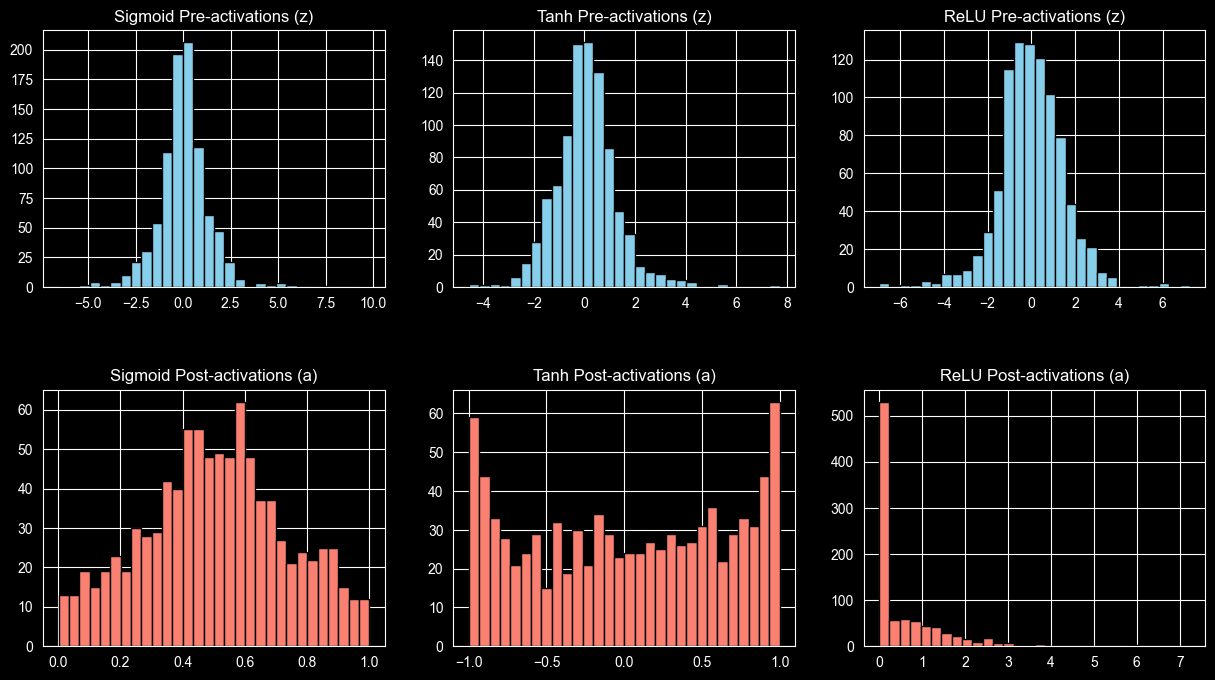

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plt.subplots_adjust(hspace=0.4)

for i, (name, (z1, a1)) in enumerate(results.items()):
    # Pre-activations (Z1)
    axes[0, i].hist(z1.flatten(), bins=30, color='skyblue', edgecolor='black')
    axes[0, i].set_title(f"{name} Pre-activations (z)")

    # Post-activations (A1)
    axes[1, i].hist(a1.flatten(), bins=30, color='salmon', edgecolor='black')
    axes[1, i].set_title(f"{name} Post-activations (a)")

plt.show()

### 1. Saturated Regions (Sigmoid and Tanh)

* **Sigmoid:** Approximately **15-20%** of post-activation values fall into the saturated regions (near 0.0 and 1.0), as seen by the significant counts at the far left and right edges of the "Sigmoid Post-activations" histogram.
* **Tanh:** A higher fraction, roughly **25-30%**, falls into saturated regions (near -1.0 and 1.0), indicated by the tall bars at both boundaries of the "Tanh Post-activations" plot.

### 2. Inactive Units (ReLU)

* **ReLU:** Roughly **50-60%** of the units are inactive. This is clearly visible in the "ReLU Post-activations" histogram, where the single bar at exactly 0 has a count exceeding 500, while all other active bins combined represent a much smaller portion of the total samples.

### 3. Why ReLU is the better default

ReLU is generally preferred for hidden layers because it avoids the **vanishing gradient problem** that plagues Sigmoid and Tanh. In the histograms, the saturated regions in the Sigmoid and Tanh plots represent areas where the function is "flat," meaning the gradient is near zero and the model will stop learning. Conversely, ReLU provides a **constant gradient of 1** for all positive values, ensuring a robust signal for backpropagation while creating **sparsity** by turning off negative neurons, which improves computational efficiency.